***Task 1 - Tensor Manipulations (Numpy)***

Tensor is a mathematical object used in ML. Types are scalar like 5, vector (1D0), matrix (2D) and tensor (3D or higher array like rgb image 3xHxW)

In [ ]:
import numpy as np
np.set_printoptions(suppress=True)   # it suppresses some float point instead of print decimal

**1) Create two sample Tensors**

In [ ]:
a = np.array([[1, 2, 3],                    # define a 2x3 matrix (dtype float32 for NN-friendly math)
              [4, 5, 6]], dtype=np.float32)
b = np.ones((2, 3), dtype=np.float32) * 10   #it prints all rows and columns in one and multipied by 10
print("a:\n", a)
print("b:\n", b)

a:
 [[1. 2. 3.]
 [4. 5. 6.]]
b:
 [[10. 10. 10.]
 [10. 10. 10.]]


**2) Element-wise addition**

In [ ]:
c_add = a + b   # both a and b are same shapes that 2x3 - 2 rows and 3 columns
print("a + b:\n", c_add)

a + b:
 [[11. 12. 13.]
 [14. 15. 16.]]


**3) Element-wise multiplication**

In [ ]:
c_mul = a * b
print("a * b:\n", c_mul)

a * b:
 [[10. 20. 30.]
 [40. 50. 60.]]


**4) Reshape a Tensor** - faster and memory friendly. Reshape - Reshape changes the view (shape) of data without altering the underlying values.

In [ ]:
r = a.reshape(3, 2)     # here we change the shape (2,3) to (3,2)
print("reshape (3,2):\n", r)

reshape (3,2):
 [[1. 2.]
 [3. 4.]
 [5. 6.]]


**5) Slicing and Indexing**

In [ ]:
print("first row:", a[0])   #print first row in a that is 0(first)
print("second column:", a[:, 1])     #: represents all rows but column 1 only
print("submatrix:\n", a[0:2, 1:3])

first row: [1. 2. 3.]
second column: [2. 5.]
submatrix:
 [[2. 3.]
 [5. 6.]]


**6) Combining Tensors (Concatenate / Stack)**
## concatenate vs stack: concatenate joins along an existing axis; stack creates a new axis ([[1, 2, 3],[4, 5, 6]])

In [ ]:
cat_cols = np.concatenate([a, b], axis=1) #axis = 1 means join side by side(columns)
print("concat cols:\n", cat_cols)

concat cols:
 [[ 1.  2.  3. 10. 10. 10.]
 [ 4.  5.  6. 10. 10. 10.]]


In [ ]:
cat_rows = np.concatenate([a, b], axis=0)  #axis = 0 means join top bottom (add rows)
print("concat rows:\n", cat_rows)

concat rows:
 [[ 1.  2.  3.]
 [ 4.  5.  6.]
 [10. 10. 10.]
 [10. 10. 10.]]


Stack means joins arrays by creating a new axis

In [ ]:
stack0  = np.stack([a, b], axis=0)
print("stack axis=0 shape:", stack0.shape)

stack axis=0 shape: (2, 2, 3)


In [ ]:
stack2  = np.stack([a, b], axis=2)
print("stack axis=2 shape:", stack2.shape)

stack axis=2 shape: (2, 3, 2)


**7) Splitting Tensors** split: split divides an array into multiple parts along a chosen axis using equal parts or index cuts.

In [ ]:
x = np.arange(12).reshape(3, 4)          # numbers 0..11 reshaped into 3x4 grid
left, right = np.split(x, 2, axis=1)            # split columns into 2 equal parts -> (3,2) and (3,2)
top, middle_bottom = np.split(x, [1], axis=0)   # split rows at index 1 -> (1,4) and (2,4)
print("left:\n", left)                          # left half of columns
print("right:\n", right)                        # right half of columns
print("TOP:\n", top)
print("MIDDLE_BOTTOM:\n", middle_bottom)        #axis = 0 - cut the arrays horizontally, axis = 1 - cut the arrays vertically for left and right


left:
 [[0 1]
 [4 5]
 [8 9]]
right:
 [[ 2  3]
 [ 6  7]
 [10 11]]
TOP:
 [[0 1 2 3]]
MIDDLE_BOTTOM:
 [[ 4  5  6  7]
 [ 8  9 10 11]]


**8) Basic math-ops**

In [ ]:
print("sum:", a.sum())   #sum=sum all elements

sum: 21.0


In [ ]:
print("mean (axis=0):", a.mean(axis=0))    #add column-wise and divided by 2

mean (axis=0): [2.5 3.5 4.5]


In [ ]:
print("max:", a.max())        #global maximum value

max: 6.0


In [ ]:
print("transpose a^T:\n", a.T)     # swap axes: (2,3) -> (3,2)

transpose a^T:
 [[1. 4.]
 [2. 5.]
 [3. 6.]]


In [ ]:
w = np.arange(6, dtype=np.float32).reshape(3, 2)
print("matrix multiply (2x3) @ (3x2):\n", a @ w)

matrix multiply (2x3) @ (3x2):
 [[16. 22.]
 [34. 49.]]


In [ ]:
print("elementwise relu:", np.maximum(a, 0))  # elements in negative only, it gives positive before it is positive so all elements are positive

elementwise relu: [[1. 2. 3.]
 [4. 5. 6.]]


***Task 2 — Neural Network Foundations (Keras)***

Keras refers to a high-level deep learning API in Python. Let me break it down clearly:

1. **Purpose**

Keras is used for building and training neural networks easily without worrying about the low-level math. It acts as a user-friendly interface on top of lower-level libraries like TensorFlow (mostly), Theano, or CNTK.

**2. Key Features**

Simple and readable syntax — you can build complex models in just a few lines.

Modular — models are built by stacking layers like Dense, Conv2D, LSTM, etc.

Supports multiple backends — although today, TensorFlow is the main backend.

Fast experimentation — good for prototyping models quickly.

In [ ]:
import tensorflow as tf                 # deep learning backend
from tensorflow import keras              # Keras high-level API
from tensorflow.keras import layers       # common layers: Dense, Dropout, etc.
tf.random.set_seed(42)                    # reproducibility for weights/init

**1) Define a simple model**

In [ ]:
model = keras.Sequential([               # Sequential means your model is a stack of layers, connected one after the other.Input flows from the first layer → hidden layers → output layer.
    layers.Input(shape=(20,)),           # placeholder shape=(20,) means each input example is a vector of 20 features.
    layers.Dense(16, activation="relu"), # Dense = fully connected layer, every neuron is connected to all inputs from the previous layer. 16-num of neurons in tis layer
    layers.Dense(3, activation="softmax")# Another fully connected layer with 3 neurons.activation="softmax" converts raw outputs into probabilities that sum to 1
])

**2) Compile the model**

In [ ]:
model.compile(                                  #This step configures the model for training. like update weights, loss and metrics to monitor
    optimizer=keras.optimizers.Adam(1e-3),      # adaptive optimizer with lr=0.001. Adam automatically adjusts learning rates for each weight, which often leads to faster convergence than basic SGD (stochastic gradient descent).
    loss="sparse_categorical_crossentropy",     # integer labels (0..2) -> sparse variant. #This is the loss function, which tells the model how bad its predictions are.You have integer labels for classes,
    metrics=["accuracy"]                         # track accuracy during training/eval
)

**3) Print model summary**

In [ ]:
model.summary()     #print param counts to catch mismatched shapes and layer shapes before training

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

Layer 1: dense (Dense)
Output Shape: (None, 16)
Param #: 336


Input shape: 20 (from Input(shape=(20,)))

Output shape: 16 → the layer has 16 neurons (each neurons has its own bias term)

Parameters:

Params=(input dimensions x neurons) + biases = (20*16)+16 = 336


Output Shape: (None, 3)
Param #: 51
Input shape: 16 (from previous layer)

Output shape: 3 → 3 neurons for 3-class classification

Parameters:= (16*3)+3 = 51

**4) Test on random data**

In [ ]:
import numpy as np                        # create synthetic data to sanity-check pipeline
X = np.random.randn(256, 20).astype("float32")  # 256 samples, each 20-D features
y = np.random.randint(0, 3, size=(256,))        # random integer class labels in [0,3)
history = model.fit(                            # quick overfit/shape sanity-check
    X, y,
    epochs=3,                                   # few epochs just to see training loop
    batch_size=32,                              # typical small batch
    validation_split=0.2                        # hold out 20% for validation
)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2836 - loss: 1.5635 - val_accuracy: 0.3654 - val_loss: 1.5002
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2907 - loss: 1.5035 - val_accuracy: 0.3654 - val_loss: 1.4673
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3057 - loss: 1.4559 - val_accuracy: 0.3654 - val_loss: 1.4376


***Task 3 — Classification: MNIST and IMDb (Keras)***

**Classification: MNIST **

What is MNIST?
MNIST is a classic computer-vision dataset of handwritten digits. It contains 70,000 grayscale images sized 28×28 pixels: 60,000 for training and 10,000 for testing. Each image shows a single digit 0–9, and the label is that digit. Pixel values are integers in the range 0–255 (darkness), which we typically rescale to [0,1] to make optimization more stable. The Keras loader returns two tuples: (x_train, y_train), (x_test, y_test), where x_* are image tensors and y_* are integer class IDs.

We often flatten each image to a 1-D vector of length 784 (28×28) when using a fully-connected (Dense) network, because Dense layers expect vectors, not 2-D grids. Convolutional networks (CNNs) can keep the 2-D shape instead. MNIST is small and clean, so it’s ideal for verifying your training loop, visualizing learning curves, and establishing quick baselines.

**A) MNIST — 0) Setup**

In [ ]:
import tensorflow as tf                 # TensorFlow/Keras
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt            # plot training curves
tf.random.set_seed(42)                     # reproducible splits/initialization

**A) MNIST — 1) Load & preprocess**
We normalize pixels to [0,1] to stabilize gradients (features on comparable scales), and we flatten 28×28 → 784 because a Dense layer expects a 1-D feature vector rather than a 2-D image grid.

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()      #70000 gray-scale images (60000 - training and 10000-testing) and loads the MNIST handwritten digit dataset.
x_train = (x_train.astype("float32") / 255.0).reshape(-1, 784)             #MNIST pixels are in [0,255] and we scale it [0,1]
x_test  = (x_test.astype("float32")  / 255.0).reshape(-1, 784)            #flatten the shape because -1 automatically computes number of examples  here it is 60000 (28*28 = 784)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)                                                                 #MNIST images: 28×28 pixels, grayscale (values 0–255).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784) (60000,) (10000, 784) (10000,)


Output:
x_train.shape = (60000, 784)

60,000 training images, each flattened to 784 features (28×28).

y_train.shape = (60000,)

60,000 labels (integers 0–9).

x_test.shape = (10000, 784)

10,000 test images, each flattened to 784 features.

y_test.shape = (10000,)

10,000 test labels.

**A) MNIST — 2) Define model**

In [ ]:
mnist_model = keras.Sequential([
    layers.Input(shape=(784,)),               # flattened each image is in pixel 28x28 image flattened to 784 features
    layers.Dense(128, activation="relu"),     # hidden layer for representation with 128 neurons , relu allows to learn complex patterns
    layers.Dropout(0.2),                      # Randomly sets 20% of the neurons to zero during training and regularize to reduce overfitting by preventing the model from relying too heavily on any one neuron.only active during training not inference
    layers.Dense(10, activation="softmax")    # 10 classes (digits 0..9)
])

**A) MNIST — 3) Compile**

In [ ]:
mnist_model.compile(
    optimizer="adam",                         # Adam works well out of the box and adjust weights automatically
    loss="sparse_categorical_crossentropy",   # integer digit labels use it only for integers and It computes how wrong the predicted probability distribution is.
    metrics=["accuracy"]                      # track accuracy
)

An **optimizer** tells the model how to update its weights during training so that the loss gets smaller.
**Adam for MNIST:**
It learns faster than plain SGD
It works well for noisy gradient problems like images
It requires almost no hyperparameter tuning
MNIST is a simple dataset → Adam achieves high accuracy quickly
Adam is the standard “works out of the box” choice.

**A) MNIST — 4) Train**

In [ ]:
history_mnist = mnist_model.fit(
    x_train, y_train,
    epochs=5,                                 # quick training for demo and the model sees all 60000 images one time
    batch_size=128,                           # larger batch speeds up on GPU/TPU
    validation_split=0.1,                     # 10% of train data for validation
    verbose=1                                 # show progress and how much output you wanted to print during training
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7905 - loss: 0.7243 - val_accuracy: 0.9563 - val_loss: 0.1720
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9342 - loss: 0.2239 - val_accuracy: 0.9637 - val_loss: 0.1263
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9521 - loss: 0.1656 - val_accuracy: 0.9693 - val_loss: 0.1049
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9609 - loss: 0.1331 - val_accuracy: 0.9720 - val_loss: 0.0920
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9667 - loss: 0.1108 - val_accuracy: 0.9743 - val_loss: 0.0867


**A) MNIST — 5) Evaluate + Plot**

MNIST — test loss: 0.0983 | test acc: 0.9705


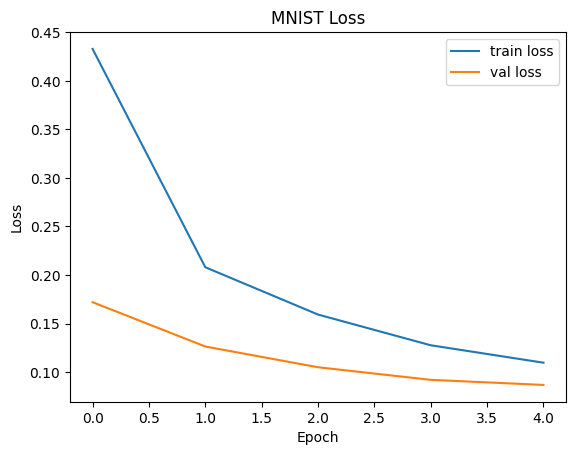

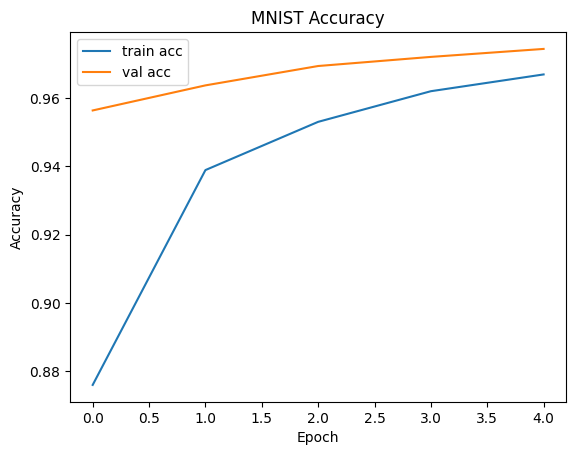

In [ ]:
test_loss, test_acc = mnist_model.evaluate(x_test, y_test, verbose=0)  # final test metrics
print(f"MNIST — test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")                # report metrics

# Plot loss over epochs to diagnose under/overfitting
plt.figure()
plt.plot(history_mnist.history["loss"], label="train loss")      # training loss curve
plt.plot(history_mnist.history["val_loss"], label="val loss")    # validation loss curve
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("MNIST Loss")
plt.show()

# Plot accuracy to see learning progress
plt.figure()
plt.plot(history_mnist.history["accuracy"], label="train acc")        # training accuracy
plt.plot(history_mnist.history["val_accuracy"], label="val acc")      # validation accuracy
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("MNIST Accuracy")
plt.show()

Output:
**MNIST Loss:** This is the model did not see the loss on the data during training(Validation curve)
(Test Curve) - THis show how the model is wrong on the training data, it also decreases.
Therefore the** model is not overfitting and also generalizes well.**

**Output:MNIST Accuracy:** As epochs increase:
Train accuracy goes from 0.88 → 0.965
Validation accuracy goes from 0.958 → 0.973
This means:
✔️ The model is learning
✔️ The model generalizes well to unseen data

Code : model.evaluate() runs the model on the test dataset (x_test, y_test) and returns:
test_loss → how wrong the model is on test data
test_acc → how many test images it correctly classified
verbose=0 → no printing of progress and just returns the numbers

Keras stores training information for each epoch:
loss
accuracy
val_loss
val_accuracy
These are inside in history_mnist.history

**Classification : IMDb(Internet Movie Database)**
The Keras IMDb dataset is a text-classification benchmark of movie reviews labeled for sentiment (binary: positive vs. negative). It includes 50,000 reviews split evenly into 25,000 train and 25,000 test, with a balanced number of positive and negative examples.
Keras provides a preprocessed version of the IMDB dataset.

***the Keras IMDB version***
Reviews are already turned into numbers:
Each word is replaced by a number (word ID). The most common words get smaller numbers. For example:
"I loved this movie" → [2, 15, 20, 6]

Limit vocabulary with num_words:
To make the model smaller and faster, you can only use the top N most frequent words. Rare words are ignored.

Reviews have different lengths:
Some reviews are very short, some are very long. But neural networks like fixed-size input, so we pad (add zeros) or truncate reviews to a set length maxlen.

**padding:** Padding makes all sequences the same length for batching.
**truncating: **Truncating shortens long sequences so they fit the maximum length.

**B) IMDb — 1) Load & preprocess**

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences  # sequence padding util
from tensorflow import keras
num_words = 10_000                      # limit vocabulary to most frequent 10k words
maxlen = 200                            # We want all reviews to have exactly 200 words (numbers) for the neural network.
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)  # load tokenized reviews
X_train = pad_sequences(X_train, maxlen=maxlen, truncating="post", padding="post")  # pad/cut to maxlen makes all review in 200 words
X_test  = pad_sequences(X_test,  maxlen=maxlen, truncating="post", padding="post")  # same for test
print(X_train.shape, X_test.shape)      # both -> (25000, 200) 25000 reviews in the training set and 200 words in each reviews

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000, 200) (25000, 200)


**Output :** X_train.shape → (25000, 200)
25,000 reviews in the training set
Each review is exactly 200 numbers long (padded or truncated)
X_test.shape → (25000, 200)
25,000 reviews in the test set
Same fixed length of 200 numbers. Data is ready for a neural network.

**B) IMDb — 2) Define model**

We learn dense token embeddings (compact semantics), average them with GAP to get a fixed-size review vector, then classify sentiment with a single sigmoid unit. embedding: An embedding maps token IDs to dense vectors capturing semantic relationships.A way to convert each word ID into a list of numbers (vector) that captures its meaning.Words with similar meaning have similar vectors.
gap: GlobalAveragePooling1D averages features over time, making a fixed-size representation.
sigmoid: Sigmoid maps inputs to (0,1), i.e., probabilities for binary tasks.the output can be treated as a probability of the review being positive.

In [ ]:
imdb_model = keras.Sequential([
    keras.layers.Embedding(input_dim=num_words, output_dim=64, input_length=maxlen),  # word embeddings and Convert word IDs into a numeric form that captures word meaning.
    keras.layers.GlobalAveragePooling1D(),                                            # average embeddings across tokens
    keras.layers.Dense(64, activation="relu"),                                        # hidden layer
    keras.layers.Dropout(0.2),                                                        # regularization and randomly ignores 20percent neurons for training
    keras.layers.Dense(1, activation="sigmoid")                                       # binary sentiment -> probability Dense + Sigmoid: Output probability of positive sentiment
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**B) IMDb — 3) Compile**

In [ ]:
imdb_model.compile(
    optimizer="adam",                    # default Adam
    loss="binary_crossentropy",          # binary labels (0/1)
    metrics=["accuracy"]                 # accuracy for readability
)

**B) IMDb — 4) Train**

In [ ]:
history_imdb = imdb_model.fit(
    X_train, y_train,
    epochs=6,                           # a few epochs for demo
    batch_size=512,                     # bigger batch for speed on accelerators
    validation_split=0.2,               # hold-out validation
    verbose=1                           # progress bar
)

Epoch 1/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5647 - loss: 0.6901 - val_accuracy: 0.7134 - val_loss: 0.6637
Epoch 2/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7115 - loss: 0.6431 - val_accuracy: 0.7720 - val_loss: 0.5500
Epoch 3/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7895 - loss: 0.5165 - val_accuracy: 0.8236 - val_loss: 0.4320
Epoch 4/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8318 - loss: 0.4018 - val_accuracy: 0.8450 - val_loss: 0.3739
Epoch 5/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8675 - loss: 0.3375 - val_accuracy: 0.8566 - val_loss: 0.3450
Epoch 6/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8820 - loss: 0.3023 - val_accuracy: 0.8564 - val_loss: 0.3324


40/40 3s 47ms/step - accuracy: 0.5647 - loss: 0.6901 - val_accuracy: 0.7134 - val_loss: 0.6637
40/40 → number of batches processed (your batch size = 512 → 25,000 samples / 512 ≈ 49, rounded to 40 here).
3s → total time for this epoch.
47ms/step → time per batch.
accuracy: 0.5647 → training accuracy (56.47%) on this epoch
loss: 0.6901 → training loss for this epoch
val_accuracy: 0.7134 → accuracy on the validation set (20% split)
val_loss: 0.6637 → validation loss for this epoch

**B) IMDb — 5) Evaluate + Plot**

IMDb — test loss: 0.3432 | test acc: 0.8519


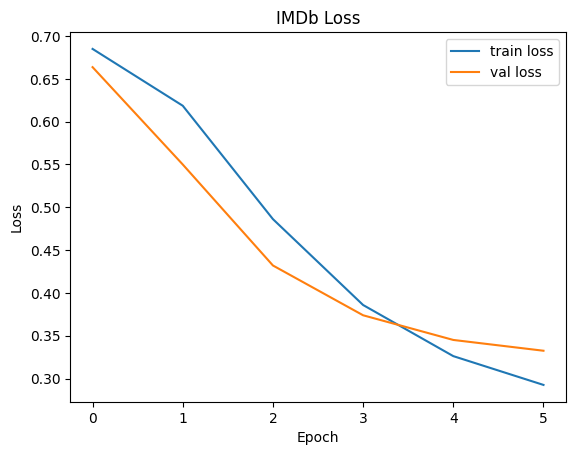

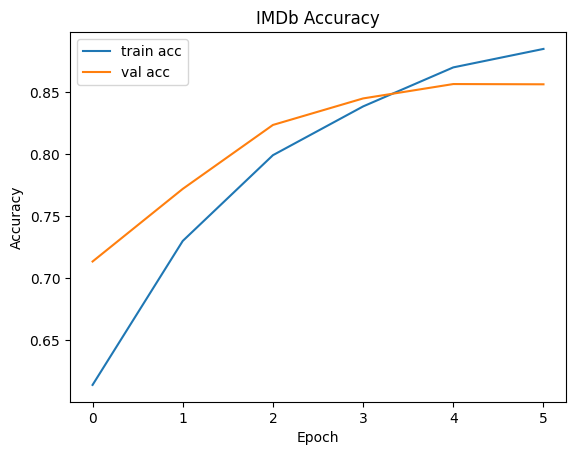

In [ ]:
loss, acc = imdb_model.evaluate(X_test, y_test, verbose=0) # test set metrics
print(f"IMDb — test loss: {loss:.4f} | test acc: {acc:.4f}")                # report

# Plot loss curves to inspect bias/variance
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history_imdb.history["loss"], label="train loss")
plt.plot(history_imdb.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("IMDb Loss")
plt.show()

# Plot accuracy curves to see performance trend
plt.figure()
plt.plot(history_imdb.history["accuracy"], label="train acc")
plt.plot(history_imdb.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("IMDb Accuracy")
plt.show()

IMDb loss decreases and accuracy increases.